In [3]:
import os
import fastf1
import pandas as pd
import numpy as np

#비가 오지 않을 때의 레이스 전략 시뮬레이션

# 1. 환경 설정 및 캐시 활성화
cache_dir = 'f1_cache'
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)
fastf1.Cache.enable_cache(cache_dir)

circuit_name = 'Belgium'

# ----------------------------------------------------
# [TRACK 1] 서킷의 역사적 매크로 데이터 수집 (과거 20개 시즌 타겟)
# ----------------------------------------------------
# 2006년부터 2025년까지의 벨기에 GP 역사적 변수 추출 (2006년은 스파 미개최로 예외처리 발생 가능)
macro_years = list(range(2006, 2026)) 
sc_events = []
sc_trigger_laps = []

print("📚 [TRACK 1] 스파 서킷 20개년 매크로 통계 수집 시작...")
for year in macro_years:
    try:
        session = fastf1.get_session(year, circuit_name, 'R')
        session.load(laps=True, telemetry=False, weather=False) # 가볍게 로드
        laps = session.laps
        
        # 세이프티 카(4) 또는 버추얼 세이프티 카(6) 발동 랩 추출
        sc_laps = laps[laps['TrackStatus'].str.contains('4|6', na=False)]['LapNumber'].unique()
        total_laps = laps['LapNumber'].max()

        # 2. 경기당 SC 발생 여부 (한 번이라도 터졌으면 1, 아니면 0)
        sc_lap_numbers = len(sc_laps)
        has_sc = 1 if sc_lap_numbers > 0 else 0
        
        if total_laps > 0:
            sc_events.append({
                'Year': year, 
                'TotalLaps': total_laps, 
                'SCLaps': sc_lap_numbers,
                'SC_Occurred': has_sc # 경기당 발생 여부 저장
            })

        if has_sc == 1:
            first_sc_lap = min(sc_laps)
            sc_trigger_laps.append(first_sc_lap)
        
    except Exception as e:
        # F1 스파 서킷이 개최되지 않은 해(예: 2006년)나 데이터 오류 자동 스킵
        continue

df_macro_sc = pd.DataFrame(sc_events)
historical_sc_prob = df_macro_sc['SCLaps'].sum() / df_macro_sc['TotalLaps'].sum() #랩 당 SC 발생 확률

race_sc_prob = df_macro_sc['SC_Occurred'].sum() / len(df_macro_sc) #경기당 SC 발생 확률

avg_sc_lap = np.mean(sc_trigger_laps) #SC 발동 시점 평균 랩
std_sc_lap = np.std(sc_trigger_laps) #SC 발동 시점 랩의 표준편차

# ----------------------------------------------------
# [TRACK 2] 최근 4개년 19인 타이어/페이스 마이크로 데이터 수집 (가중치 적용)
# ----------------------------------------------------
micro_years = [2022, 2023, 2024, 2025]
all_laps_list = []
pit_losses = []

print("\n🏎️ [TRACK 2] 최근 4개년 전수조사 및 피트 손실 계산 시작...")
weight_dict = {2025: 1.0, 2024: 0.7, 2023: 0.4, 2022: 0.1}

for year in micro_years:
    try:
        session = fastf1.get_session(year, circuit_name, 'R')
        session.load(laps=True, telemetry=False, weather=True) # 타이어 마모 분석용 상세 로드
        laps = session.laps
        
        # 1. 정상 주행 데이터 정제 (가중치 포함)
        cond_normal = laps['TrackStatus'] == '1'
        cond_no_pit = (laps['PitInTime'].isna()) & (laps['PitOutTime'].isna())
        cleaned_laps = laps[cond_normal & cond_no_pit].copy()

        weather_data = session.weather_data[['Time', 'TrackTemp']].copy()
        # 날씨 데이터와 랩 데이터를 시간 기준으로 시계열 매칭 병합
        cleaned_laps = pd.merge_asof(cleaned_laps.sort_values('Time'),
                                     weather_data.sort_values('Time'),
                                     on='Time', direction='nearest')
        # 랩 간 시간 차이가 1.5초 미만이면 'IsInTraffic' 컬럼에 1, 아니면 0으로 표시 (더티 에어 여부)
        cleaned_laps['IsInTraffic'] = np.where(cleaned_laps['Time'].diff().dt.total_seconds() < 1.5, 1, 0)

        
        cleaned_laps['Weight'] = weight_dict[year]
        cleaned_laps['Year'] = year
        cleaned_laps['LapTimeSeconds'] = cleaned_laps['LapTime'].dt.total_seconds()
        
        features = ['Year', 'Weight', 'Driver', 'Team', 'LapNumber', 'LapTimeSeconds', 'Compound', 'TyreLife', 'TrackTemp', 'IsInTraffic', 'Stint']
        all_laps_list.append(cleaned_laps[features].dropna())
        
        # 2. 피트레인 감속 손실 시간 상세 계산 (정밀도 증가)
        pit_laps = laps[laps['PitInTime'].notna() | laps['PitOutTime'].notna()]
        for idx, row in pit_laps.iterrows():
            driver = row['Driver']
            avg_normal = cleaned_laps[cleaned_laps['Driver'] == driver]['LapTimeSeconds'].mean()
            pit_lap_time = row['LapTime'].total_seconds() if pd.notna(row['LapTime']) else None
            
            if pit_lap_time and avg_normal:
                loss = pit_lap_time - avg_normal
                if 15 < loss < 40: # 아웃라이어 제거 플러그
                    pit_losses.append(loss)
    except Exception as e:
        print(f"⚠️ {year}년 마이크로 데이터 수집 실패: {e}")

df_laps = pd.concat(all_laps_list, ignore_index=True)
mean_pit_loss = np.mean(pit_losses)

# 과거 팀 이름을 현재(2026년) 존재하는 10개 팀 이름 체계로 강제 통일
team_mapping = {
    'AlphaTauri': 'RB',
    'Alfa Romeo': 'Sauber',
    'Haas F1 Team': 'Haas',
    'Aston Martin Aramco': 'Aston Martin',
    'Alpine': 'Alpine',
    'Williams': 'Williams',
    'Red Bull Racing': 'Red Bull Racing',
    'Ferrari': 'Ferrari',
    'McLaren': 'McLaren',
    'Mercedes': 'Mercedes'
}

# 수중용 타이어만 지우고, 팀 이름은 매핑을 통해 10개 팀 전체 데이터를 보존!
df_laps = df_laps[~df_laps['Compound'].isin(['INTERMEDIATE', 'WET'])].copy()
df_laps['Team'] = df_laps['Team'].replace(team_mapping)

# ----------------------------------------------------
# 최종 리포트 출력
# ----------------------------------------------------
print("\n🎯 [Step 1 완료] 완벽한 전략 데이터베이스 구축!")
print(f"1. 20개년 스파 역사상 '전체 레이스 중 SC주행' 리스크 확률: {historical_sc_prob * 100:.2f}%")
print(f"2. 실전 피트 손실 통계 (Pit Lane Loss): {mean_pit_loss:.2f} 초")
print(f"3. 머신러닝용 최근 4개년 데이터 로우 수: {len(df_laps)}개")
print(f"4. 경기당 세이프티 카(SC/VSC) 발생 확률: {race_sc_prob * 100:.2f}%")
print(f"5. SC 발동 시 평균 타이밍: 레이스 시작 후 {avg_sc_lap:.1f}바퀴 시점 (±{std_sc_lap:.1f}랩)")


📚 [TRACK 1] 스파 서킷 20개년 매크로 통계 수집 시작...


events      WARNING 	Correcting user input 'Belgium' to 'Australian Grand Prix'
core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
logger      WARNING 	Failed to load session info data!
core        WARNING 	Cannot load laps, telemetry, weather, and message data because the relevant API is not supported for this session.
core           INFO 	Finished loading data for 22 drivers: ['1', '3', '7', '16', '2', '17', '11', '14', '21', '12', '19', '22', '23', '4', '18', '20', '5', '9', '15', '8', '10', '6']
core           INFO 	Loading data for Belgian Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
logger      WARNING 	Failed to load session info data!
core        WARNING 	Cannot load laps, telemetry, weather, and message data because the 


🏎️ [TRACK 2] 최근 4개년 전수조사 및 피트 손실 계산 시작...


core        WARNING 	Fixed incorrect tyre stint information for driver '22'
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '63', '14', '16', '31', '5', '10', '23', '18', '4', '22', '24', '3', '20', '47', '6', '77', '44']
core           INFO 	Loading data for Belgian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data f


🎯 [Step 1 완료] 완벽한 전략 데이터베이스 구축!
1. 20개년 스파 역사상 '전체 레이스 중 SC주행' 리스크 확률: 6.43%
2. 실전 피트 손실 통계 (Pit Lane Loss): 18.88 초
3. 머신러닝용 최근 4개년 데이터 로우 수: 2604개
4. 경기당 세이프티 카(SC/VSC) 발생 확률: 62.50%
5. SC 발동 시 평균 타이밍: 레이스 시작 후 3.0바퀴 시점 (±3.5랩)



📈 [Step 2] XGBoost 7대 변수 통합 마모 모델링 가동...
🧹 필터링 후 남은 정예 드라이버 수: 15명
❌ 제거된 드라이버 목록: ['HUL', 'BOT', 'ZHO', 'SAR', 'PIA', 'VET', 'MSC', 'LAT', 'LAW', 'BOR', 'BEA', 'HAD', 'ANT', 'COL']

🎯 [XGBoost 모델 훈련 및 검증 완료]
  - 랩당 예측 오차 범위 (RMSE): ±0.539 초
  - 모델의 변수 설명력 (R² Score): 87.20%


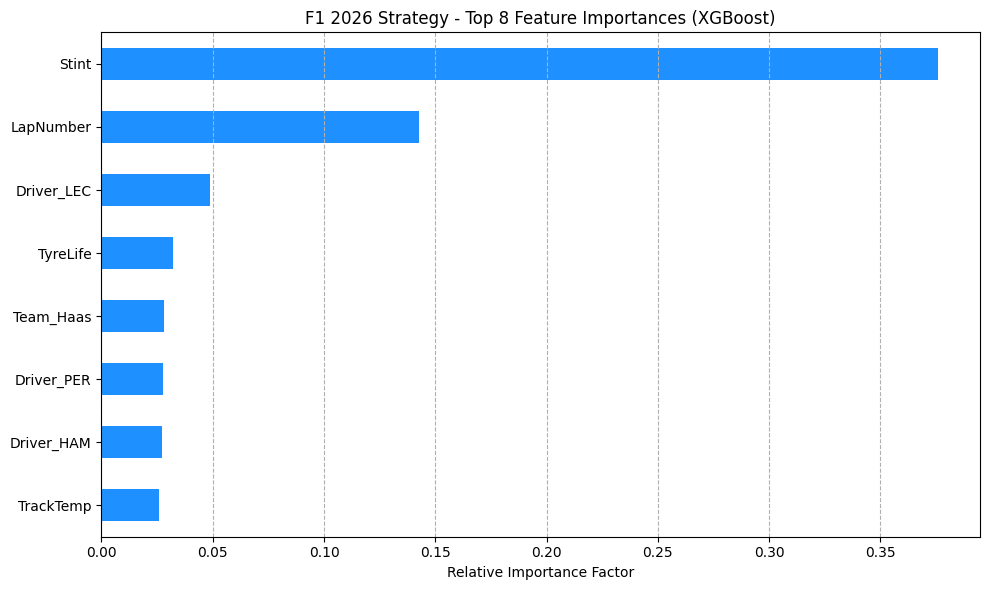

In [4]:
import xgboost as xgb #머신러닝 모델링 라이브러리
from sklearn.model_selection import train_test_split #데이터 분할 라이브러리
from sklearn.metrics import mean_squared_error, r2_score #모델 평가 지표 라이브러리
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("\n📈 [Step 2] XGBoost 7대 변수 통합 마모 모델링 가동...")

# 베이스 페이스 계산: 각 드라이버별 상위 10% 랩타임 평균을 기준으로 설정
base_pace = df_laps.groupby(['Year', 'Driver'])['LapTimeSeconds'].transform(lambda x: x.nsmallest(int(len(x)*0.1)+1).mean())

# 랩타임 대비 베이스 페이스 차이 계산
df_laps['PaceDelta'] = df_laps['LapTimeSeconds'] - base_pace

driver_lap_counts = df_laps['Driver'].value_counts()
min_lap_threshold = 100
frequent_drivers = driver_lap_counts[driver_lap_counts >= min_lap_threshold].index

df_laps = df_laps[df_laps['Driver'].isin(frequent_drivers)].copy()
print(f"🧹 필터링 후 남은 정예 드라이버 수: {df_laps['Driver'].nunique()}명")
print(f"❌ 제거된 드라이버 목록: {list(driver_lap_counts[driver_lap_counts < min_lap_threshold].index)}")


# 1. 범주형 데이터(Compound, Driver, Team) 원핫 인코딩
df_ml = pd.get_dummies(df_laps, columns=['Compound', 'Driver', 'Team'], drop_first=False)

# 2. 독립변수(X)와 종속변수(y) 분리
X_features = df_ml.drop(columns=['LapTimeSeconds','PaceDelta', 'Year'])
y_target = df_ml['PaceDelta']

# 데이터 분할 (8:2)
X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.2, random_state=42)

# 가중치 분리
train_weights = X_train['Weight'].values
test_weights = X_test['Weight'].values

X_train_final = X_train.drop(columns=['Weight'])
X_test_final = X_test.drop(columns=['Weight'])

# 3. XGBoost Hyperparameter 설정 및 학습
# 과적합을 막고 예측의 범용성을 넓히기 위해 트리 깊이를 5로 제한합니다.
xgb_strategy_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.04,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_strategy_model.fit(X_train_final, y_train, sample_weight=train_weights)

# 4. 모델 검증
y_pred = xgb_strategy_model.predict(X_test_final)
rmse = np.sqrt(mean_squared_error(y_test, y_pred, sample_weight=test_weights))
r2 = r2_score(y_test, y_pred, sample_weight=test_weights)

print("\n🎯 [XGBoost 모델 훈련 및 검증 완료]")
print(f"  - 랩당 예측 오차 범위 (RMSE): ±{rmse:.3f} 초")
print(f"  - 모델의 변수 설명력 (R² Score): {r2 * 100:.2f}%")

# 5. 전략의 핵심: 피처 변수 중요도 확인
importances = xgb_strategy_model.feature_importances_
feat_importances = pd.Series(importances, index=X_train_final.columns)

plt.figure(figsize=(10, 6))
feat_importances.nlargest(8).plot(kind='barh', color='dodgerblue')
plt.title("F1 2026 Strategy - Top 8 Feature Importances (XGBoost)")
plt.xlabel("Relative Importance Factor")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--')
plt.tight_layout()
plt.show()

In [7]:
import numpy as np
import pandas as pd
import time

print("🎯 [Step 3 통합 엔진] 초고속 시뮬레이터 가동 준비...")

# ====================================================================
# 🗂️ 1단계: 가능한 모든 상황의 '사전 매트릭스(Look-up Table)' 딱 한 번 생성
# ====================================================================
print("⚡ [Matrix Build] 1랩부터 44랩까지 발생 가능한 5,808가지 조합 사전 연산 시작...")
start_matrix_time = time.time()

TOTAL_LAPS = 44
RUS_BASE_PACE = 105.0  # 조지 러셀의 기준 랩타임 (초)

# 격자(Grid) 범위를 생성합니다.
laps = np.arange(1, TOTAL_LAPS + 1)
tyre_lives = np.arange(1, TOTAL_LAPS + 1)
compounds = ['SOFT', 'MEDIUM', 'HARD']
stints = [1, 2, 3]

# 고정 환경 변수 (온도 변동과 트래픽 패널티는 루프 안에서 가볍게 후처리할 것이므로 여기선 고정)
FIXED_TRACK_TEMP = 35.0 
FIXED_TRAFFIC = 0

grid_rows = []
for lap in laps:
    for tyre_life in tyre_lives:
        for comp in compounds:
            for stint in stints:
                grid_rows.append({
                    'LapNumber': lap,
                    'TyreLife': tyre_life,
                    'TrackTemp': FIXED_TRACK_TEMP,
                    'IsInTraffic': FIXED_TRAFFIC,
                    'Stint': stint,
                    'Compound_HARD': 1 if comp == 'HARD' else 0,
                    'Compound_MEDIUM': 1 if comp == 'MEDIUM' else 0,
                    'Compound_SOFT': 1 if comp == 'SOFT' else 0,
                    'Driver_RUS': 1
                })

df_grid = pd.DataFrame(grid_rows)

# XGBoost 모델이 학습했던 X_train_final의 모든 컬럼(전구들)을 순회합니다.
for col in X_train_final.columns:
    # 만약 현재 df_grid에 그 컬럼이 없다면 (예: Driver_ALB, Team_Alpine 등)
    if col not in df_grid.columns:
        df_grid[col] = 0  # 조지 러셀의 레이스이므로 타 드라이버/팀 전구는전부 0(False)으로 초기화!

# 머신러닝 모델이 기억하는 독립변수 컬럼 순서와 100% 일치시킵니다.
df_grid_final = df_grid[X_train_final.columns]

# 🔥 [핵심] XGBoost 모델에게 딱 한 번만 쿼리를 날려 모든 평행우주의 정답을 한 번에 획득!
predicted_deltas = xgb_strategy_model.predict(df_grid_final)
df_grid['Predicted_Time'] = RUS_BASE_PACE + predicted_deltas

# O(1) 속도로 초고속 검색이 가능하도록 (Lap, TyreLife, Compound, Stint)를 Key로 하는 딕셔너리 매트릭스로 변환
# 데이터프레임에서 최댓값 전구가 켜진 컴파운드 문자열을 역산하여 키값으로 씁니다.
df_grid['CompName'] = df_grid[['Compound_SOFT', 'Compound_MEDIUM', 'Compound_HARD']].idxmax(axis=1).str.replace('Compound_', '')
lap_time_lookup = df_grid.set_index(['LapNumber', 'TyreLife', 'CompName', 'Stint'])['Predicted_Time'].to_dict()

print(f"✅ 사전 매트릭스 구축 완료! (소요 시간: {time.time() - start_matrix_time:.2f}초 / 생성된 정답 수: {len(lap_time_lookup)}개)")


# ====================================================================
# ⏱️ 2단계: 사전 매트릭스에서 빛의 속도로 랩타임을 꺼내오는 고속 헬퍼 함수
# ====================================================================
def predict_lap_time_fast(lap_number, tyre_life, compound, stint, is_in_traffic, track_temp):
    """
    XGBoost 모델을 호출하지 않고, 메모리에 적재된 사전 매트릭스(딕셔너리)에서 
    값만 다이렉트 낚아채 오기 때문에 연산 속도가 무한에 가깝습니다.
    """
    # 매트릭스에서 기본 마모 페이스 추출 (만약 예외 상황 시 베이스 페이스 반환)
    base_lap_time = lap_time_lookup.get((lap_number, tyre_life, compound, stint), RUS_BASE_PACE)
    
    # [후처리 가공] 노면 온도가 기준(35도)보다 높거나 낮을 때의 미세 변화 및 트래픽 패널티 적용
    # 이 간단한 사칙연산은 루프 속도에 아무런 영향을 주지 않습니다.
    temp_delta = (track_temp - 35.0) * 0.05  # 1도 높을 때마다 0.05초 페이스 저하 가정
    traffic_penalty = 0.8 if is_in_traffic == 1 else 0.0
    
    return base_lap_time + temp_delta + traffic_penalty


# ====================================================================
# 🎲 3단계: 몬테카를로 실전 가상 레이스 루프 엔진 (10,000회 구동)
# ====================================================================
PIT_LOSS_DRY = 18.88          
PIT_LOSS_SC = 12.50           
SC_PROB = 0.625               
SC_AVG_LAP = 3.0              
SC_STD_LAP = 3.5              

def run_race_simulation_fast(pit_laps, strategy_compounds, track_temp_profile):
    total_race_time = 0.0
    current_tyre_life = 1
    current_stint = 1
    current_compound = strategy_compounds[0]
    
    # 세이프티 카 난수 이벤트 발생 여부 결정
    has_sc_this_race = 1 if np.random.rand() < SC_PROB else 0
    sc_trigger_lap = int(np.random.normal(SC_AVG_LAP, SC_STD_LAP)) if has_sc_this_race else -1
    sc_trigger_lap = max(1, min(sc_trigger_lap, TOTAL_LAPS)) 
    
    for lap in range(1, TOTAL_LAPS + 1):
        is_in_traffic = 1 if np.random.rand() < 0.20 else 0
        track_temp = track_temp_profile[lap - 1]
        
        # 🔥 [변경점] 이전의 무거운 모델 호출 함수 대신, 방금 만든 초고속 매트릭스 헬퍼 함수를 호출!
        lap_time = predict_lap_time_fast(lap, current_tyre_life, current_compound, current_stint, is_in_traffic, track_temp)
        
        if has_sc_this_race and (sc_trigger_lap <= lap <= sc_trigger_lap + 3):
            lap_time += 15.0 # SC 상황 서행 누적
            
        total_race_time += lap_time
        
        # 피트스톱 타이밍 체크 및 상태 스위칭
        if lap in pit_laps and current_stint <= len(pit_laps):
            if has_sc_this_race and (sc_trigger_lap <= lap <= sc_trigger_lap + 3):
                total_race_time += PIT_LOSS_SC
            else:
                total_race_time += PIT_LOSS_DRY
                
            current_compound = strategy_compounds[current_stint]
            current_tyre_life = 1
            current_stint += 1
        else:
            current_tyre_life += 1
            
    return total_race_time


# ====================================================================
# 🚀 4단계: 실전 시뮬레이션 가동 및 리포트 출력
# ====================================================================
SIM_COUNT = 10000 
np.random.seed(42)
sim_track_temp = [32.0 + (i * 0.15) for i in range(TOTAL_LAPS)]

scenarios = {
    "Plan A (1스톱 정석): 15랩 피트인 [M ➡️ H]": {"pit": [15], "tyres": ["MEDIUM", "HARD"]},
    "Plan B (1스톱 연장): 20랩 피트인 [M ➡️ H]": {"pit": [20], "tyres": ["MEDIUM", "HARD"]},
    "Plan C (2스톱 공격): 12랩, 26랩 피트인 [M ➡️ M ➡️ S]": {"pit": [12, 26], "tyres": ["MEDIUM", "MEDIUM", "SOFT"]}
}

results_summary = {}

print(f"\n🎲 무한 루프 시작: 총 {SIM_COUNT}회의 가상 레이스 평행우주 시뮬레이션 돌리는 중...")
start_sim_time = time.time()

for name, config in scenarios.items():
    sim_times = []
    for _ in range(SIM_COUNT):
        # 초고속 엔진 구동
        res_time = run_race_simulation_fast(config["pit"], config["tyres"], sim_track_temp)
        sim_times.append(res_time)
    
    results_summary[name] = {
        "MeanTotalTime": np.mean(sim_times),
        "BestCaseTime": np.min(sim_times),
        "WorstCaseTime": np.max(sim_times)
    }

print(f"✅ 시뮬레이션 종료! (소요 시간: {time.time() - start_sim_time:.2f}초)")

# 최종 리포트 브리핑
print("\n🏁 [Ultimate Step 3 완료] 조지 러셀을 위한 최적의 전략 포트폴리오 리포트:\n")
df_res = pd.DataFrame(results_summary).T
df_res['Mean_Formatted'] = df_res['MeanTotalTime'].apply(lambda x: f"{int(x//60)}분 {int(x%60)}초")
print(df_res[['Mean_Formatted', 'BestCaseTime', 'WorstCaseTime']])

🎯 [Step 3 통합 엔진] 초고속 시뮬레이터 가동 준비...
⚡ [Matrix Build] 1랩부터 44랩까지 발생 가능한 5,808가지 조합 사전 연산 시작...
✅ 사전 매트릭스 구축 완료! (소요 시간: 0.16초 / 생성된 정답 수: 17424개)

🎲 무한 루프 시작: 총 10000회의 가상 레이스 평행우주 시뮬레이션 돌리는 중...
✅ 시뮬레이션 종료! (소요 시간: 1.07초)

🏁 [Ultimate Step 3 완료] 조지 러셀을 위한 최적의 전략 포트폴리오 리포트:

                                            Mean_Formatted  BestCaseTime  \
Plan A (1스톱 정석): 15랩 피트인 [M ➡️ H]                  79분 27초   4723.291351   
Plan B (1스톱 연장): 20랩 피트인 [M ➡️ H]                  79분 37초   4734.177296   
Plan C (2스톱 공격): 12랩, 26랩 피트인 [M ➡️ M ➡️ S]        79분 39초   4735.639549   

                                             WorstCaseTime  
Plan A (1스톱 정석): 15랩 피트인 [M ➡️ H]              4798.491351  
Plan B (1스톱 연장): 20랩 피트인 [M ➡️ H]              4808.577296  
Plan C (2스톱 공격): 12랩, 26랩 피트인 [M ➡️ M ➡️ S]    4813.239549  
